# Company Reviews Analytics

## Project Objective

The goal of this project is to analyze company review data and build a complete analytics pipeline using:

- Python
- Pandas
- PostgreSQL
- FastAPI
- Streamlit
- Docker
- Render

## Dataset

The dataset was obtained from Kaggle using the Kaggle API.

Dataset: Company Reviews

### Download Command

```bash
kaggle datasets download vaghefi/company-reviews

## Data Loading

We begin by loading the data into a pandas dataframe

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/raw/company_data.csv')
df.head()

,Name,Rating,Company_type,Reviews,Salaries,Cities
0,TCS,3.3,IT Services & Consulting,1.1L Reviews,9.9L Salaries,Bengaluru
1,Accenture,3.7,IT Services & Consulting,72k Reviews,6.5L Salaries,Bengaluru
2,Wipro,3.6,IT Services & Consulting,63.9k Reviews,4.8L Salaries,Hyderabad
3,Cognizant,3.6,IT Services & Consulting,60.3k Reviews,6L Salaries,Hyderabad
4,Capgemini,3.7,IT Services & Consulting,51.9k Reviews,4.8L Salaries,Bengaluru


# Data Overview

We inspect the structure of the dataset, including the number of rows, columns, and data types.

In [3]:
df.shape

(9978, 6)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9978 entries, 0 to 9977
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          9978 non-null   str    
 1   Rating        9978 non-null   float64
 2   Company_type  9978 non-null   str    
 3   Reviews       9978 non-null   str    
 4   Salaries      9978 non-null   str    
 5   Cities        9625 non-null   str    
dtypes: float64(1), str(5)
memory usage: 1.1 MB


## Data Quality Checks

We check for missing values and duplicate records to ensure data integrity before analysis.

In [4]:
df.isnull().sum()

Name              0
Rating            0
Company_type      0
Reviews           0
Salaries          0
Cities          353
dtype: int64

It has been identified that the `Cities` column has 353 missing values

In [33]:
df.duplicated().sum()


np.int64(500)

It has been identifed that the dataset has 500 duplicated rows.

## Data Cleaning
We proceed to cleaning the dataset before analysis by removing the identified duplicated rows, and identified missing values.

### Missing Values

The `Cities` column contained 353 missing values out of approximately 9,978 records (~3.5%).

Since the project aims to perform city-level analysis and the missing proportion is relatively small, these rows were removed to maintain data quality and avoid introducing uncertainty through imputation.

In [5]:
# Always make a copy of the original df when cleaning it up
df1 = df.copy() #Create new df
df1 = df1.dropna(subset='Cities')

In [6]:
# Check to see if the missing rows are removed
df1.isnull().sum()

Name            0
Rating          0
Company_type    0
Reviews         0
Salaries        0
Cities          0
dtype: int64

The `Cities` column has no missing values after the cleanup.

### Duplicate Values

The dataset contained 500 duplicated values initially.

Since the project aims to perform analysis, we do not want duplicated data inflating the results and these duplicated rows are reomved

In [7]:
df1[df1.duplicated(keep=False)].head(6)

,Name,Rating,Company_type,Reviews,Salaries,Cities
359,Sammaan Capital Limited,3.8,NBFC,2.5k Reviews,5.8k Salaries,Gurugram
360,Sammaan Capital Limited,3.8,NBFC,2.5k Reviews,5.8k Salaries,Gurugram
499,R.R. Donnelley,3.6,Marketing & Advertising,1.9k Reviews,10.2k Salaries,Chennai
501,R.R. Donnelley,3.6,Marketing & Advertising,1.9k Reviews,10.2k Salaries,Chennai
1119,Amphenol Interconnect,4.3,Electrical Equipment,930 Reviews,3.6k Salaries,Pune
1120,Amphenol Interconnect,4.3,Electrical Equipment,930 Reviews,3.6k Salaries,Pune


The above was used to view a subset of the duplicated rows to see if there are true duplicates in the dataset. As it has been confirmed, they can be removed as they will distort the results.

In [8]:
df1 = df1.drop_duplicates()
df1

,Name,Rating,Company_type,Reviews,Salaries,Cities
0,TCS,3.3,IT Services & Consulting,1.1L Reviews,9.9L Salaries,Bengaluru
1,Accenture,3.7,IT Services & Consulting,72k Reviews,6.5L Salaries,Bengaluru
2,Wipro,3.6,IT Services & Consulting,63.9k Reviews,4.8L Salaries,Hyderabad
3,Cognizant,3.6,IT Services & Consulting,60.3k Reviews,6L Salaries,Hyderabad
4,Capgemini,3.7,IT Services & Consulting,51.9k Reviews,4.8L Salaries,Bengaluru
...,...,...,...,...,...,...
9973,Brinks Arya India,4.1,Financial Services,107 Reviews,211 Salaries,Mumbai
9974,TMI Group,3.8,Recruitment,107 Reviews,419 Salaries,Hyderabad
9975,Kreate Energy,3.3,Power,107 Reviews,355 Salaries,New Delhi
9976,Op Jindal University,3.8,Education & Training,107 Reviews,381 Salaries,Sonipat


In [9]:
df1.shape

(9150, 6)

After removing the duplicated values, the dataset has now 9150 rows presents as 475 rows of duplicated data have been removed.

The dataframe now has no duplicated rows nor does it have any missing values. The analysis process can process.

In [46]:
df1.head()

,Name,Rating,Company_type,Reviews,Salaries,Cities
0,TCS,3.3,IT Services & Consulting,1.1L Reviews,9.9L Salaries,Bengaluru
1,Accenture,3.7,IT Services & Consulting,72k Reviews,6.5L Salaries,Bengaluru
2,Wipro,3.6,IT Services & Consulting,63.9k Reviews,4.8L Salaries,Hyderabad
3,Cognizant,3.6,IT Services & Consulting,60.3k Reviews,6L Salaries,Hyderabad
4,Capgemini,3.7,IT Services & Consulting,51.9k Reviews,4.8L Salaries,Bengaluru


## Converting Reviews and Salaries to Numeric Values

The `Reviews` and `Salaries` columns contain abbreviated values represented as text strings. Before performing any numerical analysis, these values need to be converted into standard numeric format.

Examples from the dataset include:

| Original Value | Meaning |
|---------------|---------|
| 72k Reviews | 72,000 Reviews |
| 63.9k Reviews | 63,900 Reviews |
| 1.1L Reviews | 110,000 Reviews |
| 96.1k Salaries | 96,100 Salaries |
| 6L Salaries | 600,000 Salaries |
| 9.9L Salaries | 990,000 Salaries |

### Abbreviation Definitions

- **k** = Thousand (1,000)
- **L** = Lakh (100,000)

The abbreviation **L** follows the Indian numbering system, where:

```text
1 Lakh = 100,000
```

To support aggregation, sorting, and statistical analysis, these values were converted into numeric columns:
- `Reviews_Count`
- `Salary_Submissions`

### Step 1: Create the conversion function

In [10]:
def convert_abbreviated_number(value):
    """
    Convert values  such as:
    72k Reviews -> 72000
    1.1L Reviews -> 110000
    96.1k Salaries ->  96100
    """

    value = str(value).strip()

    # Remove text labels
    value = value.replace(' Reviews', '')
    value = value.replace(' Salaries', '')
    # Handle missing values
    if value == '--':
        return None
    if value.endswith('k'):
        return float(value[:-1]) * 1_000
    elif value.endswith('L'):
        return float(value[:-1]) * 100_000
    else:
        return float(value)

### Step 2: Create new numeric columns

In [11]:
df1['Reviews_Count'] = df1['Reviews'].apply(convert_abbreviated_number)
df1['Salary_Submissions'] = df1['Salaries'].apply(convert_abbreviated_number)


In [12]:
df1

,Name,Rating,Company_type,Reviews,Salaries,Cities,Reviews_Count,Salary_Submissions
0,TCS,3.3,IT Services & Consulting,1.1L Reviews,9.9L Salaries,Bengaluru,110000.0,990000.0
1,Accenture,3.7,IT Services & Consulting,72k Reviews,6.5L Salaries,Bengaluru,72000.0,650000.0
2,Wipro,3.6,IT Services & Consulting,63.9k Reviews,4.8L Salaries,Hyderabad,63900.0,480000.0
3,Cognizant,3.6,IT Services & Consulting,60.3k Reviews,6L Salaries,Hyderabad,60300.0,600000.0
4,Capgemini,3.7,IT Services & Consulting,51.9k Reviews,4.8L Salaries,Bengaluru,51900.0,480000.0
...,...,...,...,...,...,...,...,...
9973,Brinks Arya India,4.1,Financial Services,107 Reviews,211 Salaries,Mumbai,107.0,211.0
9974,TMI Group,3.8,Recruitment,107 Reviews,419 Salaries,Hyderabad,107.0,419.0
9975,Kreate Energy,3.3,Power,107 Reviews,355 Salaries,New Delhi,107.0,355.0
9976,Op Jindal University,3.8,Education & Training,107 Reviews,381 Salaries,Sonipat,107.0,381.0


### Step 3: Check missing values

In [13]:
df1.isnull().sum()

Name                  0
Rating                0
Company_type          0
Reviews               0
Salaries              0
Cities                0
Reviews_Count         0
Salary_Submissions    3
dtype: int64

After the conversions, there are now 3 missing values in the `Salary_Submissions` column.

### Step 4: Remove missing values

In [14]:
df1 = df1.dropna(subset='Salary_Submissions')

### Step 5: Convert to integers

In [15]:
df1['Reviews_Count'] = df1['Reviews_Count'].astype(int)
df1['Salary_Submissions'] = df1['Salary_Submissions'].astype(int)

In [16]:
df1.head() # inspect results

,Name,Rating,Company_type,Reviews,Salaries,Cities,Reviews_Count,Salary_Submissions
0,TCS,3.3,IT Services & Consulting,1.1L Reviews,9.9L Salaries,Bengaluru,110000,990000
1,Accenture,3.7,IT Services & Consulting,72k Reviews,6.5L Salaries,Bengaluru,72000,650000
2,Wipro,3.6,IT Services & Consulting,63.9k Reviews,4.8L Salaries,Hyderabad,63900,480000
3,Cognizant,3.6,IT Services & Consulting,60.3k Reviews,6L Salaries,Hyderabad,60300,600000
4,Capgemini,3.7,IT Services & Consulting,51.9k Reviews,4.8L Salaries,Bengaluru,51900,480000


### Data Quality Investigation

While converting the `Reviews` and `Salaries` columns into numeric values, the transformation process failed with a `ValueError`.

Upon investigation, it was discovered that several records contained the value:

-- Salaries

These values represented missing salary submission information stored as text rather than true null values.

Because these values were not identified during the initial missing value assessment, additional cleaning was performed to convert them to nulls before proceeding with the analysis.

## Data Analysis

After cleaning the data, this is where now we answer business question by performing analysis on the cleaned dataset

## Business Questions

1. Which companies have the highest ratings?
2. Which companies have the lowest ratings?
3. Which cities have the highest average company ratings?
4. Which cities generate the most employee reviews?
5. Which industries receive the highest ratings?
6. Which companies have the most reviews?
7. Is there a relationship between review volume and company rating?

## Question 1: Which companies have the highest ratings?

To identify the highest-rated companies, the dataset was sorted by the `Rating` column in descending order and the top 10 companies were selected.


In [112]:
top_rated_company = df1[['Name', 'Rating']].nlargest(10, columns='Rating').reset_index(drop=True)
top_rated_company

,Name,Rating
0,Marpu Foundation,4.9
1,Tekwissen,4.9
2,Royal Migration Solutions,4.9
3,Hire In Global,4.9
4,Lavender Technology,4.9
5,InternEzy,4.9
6,ExportersIndia,4.9
7,Matrimonialsindia,4.9
8,KaaShiv InfoTech Company,4.9
9,TourTravelWorld.Com,4.9


### Findings

Several companies share the highest observed rating of **4.9**. The table below displays the top-rated companies in the dataset.

### Interpretation

The highest rating observed in the dataset is 4.9. Multiple companies achieved this rating, indicating that there is no single highest-rated company.

## Question 2: Which companies have the lowest ratings?

To identify the lowest-rated companies, the dataset was sorted by the `Rating` column in ascending order and the top 10 companies were selected.


In [116]:
top_rated_company = df1[['Name', 'Rating']].nsmallest(10, columns='Rating').reset_index(drop=True)
top_rated_company

,Name,Rating
0,DM Immigration Consultant,1.0
1,Future Market Insights,1.6
2,Ascentrik Research Services,1.8
3,Paperpedia,1.9
4,31 Parallel,1.9
5,Royal Research,2.0
6,TalentServe,2.0
7,Brane Enterprises,2.1
8,Lido Learning,2.1
9,Sendan International Co,2.1


### Interpretation
The lowest rating observed from the dataset is 1.0. The company in question that achieved this is `DM Immigration Consultant`.

## Question 3: Which cities have the highest average company ratings?

To identify the cities with the highest average company ratings, the dataset was grouped by the `Cities` column and the mean rating was calculated for each city. The resulting averages were then sorted in descending order to highlight the highest-rated cities.

In [138]:
higest_average_rating = df1.groupby('Cities').agg({'Rating': 'mean'}).sort_values(by='Rating', ascending=False).head(10).reset_index()
higest_average_rating 

,Cities,Rating
0,Mohali,4.70
1,London,4.70
2,Aligarh,4.65
3,Nagercoil,4.50
4,New York,4.50
5,Thane,4.50
6,Shahdol,4.40
7,Singapore,4.40
8,Neyveli,4.40
9,Lalitpur,4.30


### Findings

Mohali and London have the highest average company rating of **4.70**, followed by Aligarh with an average rating of **4.65**.

## Question 4: Which cities generate the most employee reviews?

To identify the cities that generate the most emplyee reviews, the dataset was grouped by the `Cities` column and the sum of the  review count was calculated for each city. The resulting values were then sorted in descending order to highlight the cities with the most employee reviews.

In [146]:
# analysis code
df1.groupby('Cities').agg({'Reviews_Count': 'sum'}).head(10).sort_values(by='Reviews_Count', ascending=False).reset_index()

,Cities,Reviews_Count
0,Ahmedabad,96129
1,Agra,2050
2,Abu Dhabi,1748
3,Al Jubail,1215
4,Alwar,1052
5,Ahilyanagar,586
6,Abu Road,327
7,Aligarh,300
8,Al Khobar,142
9,Ajmer,117


### Findings

Ahmedabad has the highest generated employee reviews with a total of **96129** employee reviews.

## Question 5: Which industries receive the highest ratings?

To identify the industries that recive the highest rating, the dataset was grouped by the `Company_type` column and the average rating was calculated for each company type. The resulting values were then sorted in descending order to highlight the industires that receive the highest ratings.

In [157]:
df1.groupby('Company_type').agg({'Rating': 'mean'}).sort_values(by='Rating', ascending=False).head(10).reset_index()

,Company_type,Rating
0,Government,4.021429
1,Ports & Shipping,3.996154
2,Non-Profit,3.968519
3,Sports & Recreation,3.966667
4,Defence & Aerospace,3.945455
5,Hospitality,3.938532
6,NBFC,3.900000
7,Building Material,3.899275
8,Oil & Gas,3.899065
9,Metals & Mining,3.894253


### Findings

Government has the industry that receives the highest rating with an average of **4.02** rating.


## Question 6: Which companies have the most reviews?

To identify the company with the most reviews, the dataset was limited to seeing only relvant columns i.e. `Name` and `Reviews_Count`. The dataset was then orderded from the highest review counts to the lowest to observe the company with the most reviews.

In [158]:
df1.head()

,Name,Rating,Company_type,Reviews,Salaries,Cities,Reviews_Count,Salary_Submissions
0,TCS,3.3,IT Services & Consulting,1.1L Reviews,9.9L Salaries,Bengaluru,110000,990000
1,Accenture,3.7,IT Services & Consulting,72k Reviews,6.5L Salaries,Bengaluru,72000,650000
2,Wipro,3.6,IT Services & Consulting,63.9k Reviews,4.8L Salaries,Hyderabad,63900,480000
3,Cognizant,3.6,IT Services & Consulting,60.3k Reviews,6L Salaries,Hyderabad,60300,600000
4,Capgemini,3.7,IT Services & Consulting,51.9k Reviews,4.8L Salaries,Bengaluru,51900,480000


In [178]:
company_most_reviews = df1[['Name', 'Reviews_Count']].sort_values(by='Reviews_Count', ascending=False).head(10).reset_index(drop=True)
company_most_reviews

,Name,Reviews_Count
0,TCS,110000
1,Accenture,72000
2,Wipro,63900
3,Cognizant,60300
4,Capgemini,51900
5,HDFC Bank,51100
6,Infosys,47700
7,ICICI Bank,45200
8,HCLTech,44900
9,Tech Mahindra,42600


### Findings

TCS has the highest number of employee reviews in the dataset, with a total of 110,000 reviews. Accenture follows with 72,000 reviews, while Wipro ranks third with 63,900 reviews.

This suggests that TCS has significantly higher employee engagement on the platform compared to other companies in the dataset.

## Question 7: Is there a relationship between review volume and company rating?

To investigate whether companies with a higher number of reviews tend to receive higher ratings, a scatter plot was created using the `Reviews_Count` and `Rating` columns.

A correlation analysis was also performed to quantify the strength and direction of the relationship between review volume and company rating.

- `Reviews_Count` was used as the independent variable (X-axis).
- `Rating` was used as the dependent variable (Y-axis).

This analysis aims to determine whether review volume is associated with higher or lower company ratings.

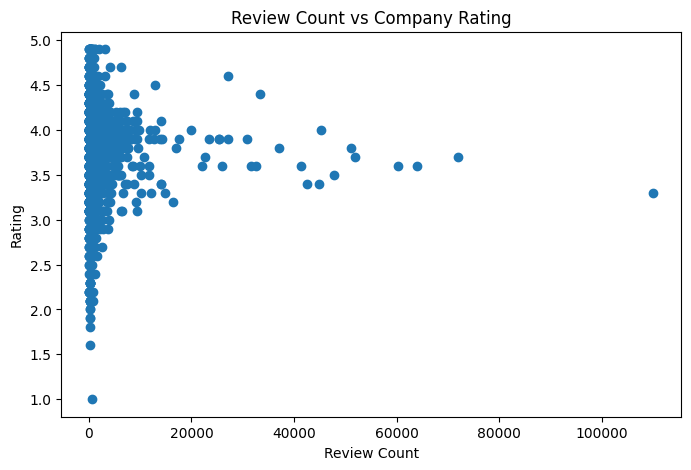

In [186]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df1['Reviews_Count'],
    df1['Rating']
)

plt.xlabel('Review Count')
plt.ylabel('Rating')
plt.title('Review Count vs Company Rating')

plt.show()

In [187]:
df1['Reviews_Count'].corr(df1['Rating'])

np.float64(0.014698175978085435)

### Final Step - Export the cleaned dataset

Once the data has been cleaned and has been removed of any duplicated values, missing values, or even correctly converting data types, we now export the results in order to use the data file for other programs.

In [1]:
df1.to_csv(
    '../data/processed/cleaned_company_data.csv',
    index=False
)

NameError: name 'df1' is not defined

In [18]:
df1.

Name                  0
Rating                0
Company_type          0
Reviews               0
Salaries              0
Cities                0
Reviews_Count         0
Salary_Submissions    0
dtype: int64